<a href="https://colab.research.google.com/github/chizkidd/deep-learning-models/blob/main/pytorch/rnn/rnn-char-gru-tinyshakespeare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [1]:
%%capture
!pip install watermark
!pip install torchinfo datasets

In [2]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch: 2.10.0+cu128



# Character-Level GRU (Char-GRU) Language Model on Tiny Shakespeare

The network in this notebook is an implementation of a **Character-Level Gated Recurrent Unit (Char-GRU)** network **[2]** trained on the Tiny Shakespeare dataset **[7]**. Moving from word-level classification to character-level generation is the "ultimate test" for a recurrent model. While a classifier identifies a label, a **Language Model (LM)** must learn the very fabric of language: spelling, punctuation, syntax, and even the "voice" of a specific author—one character at a time.

<br><br>

**Network Architecture:**

A Char-GRU is a **Many-to-Many** architecture. Unlike a classifier model that only cares about the final state, this model produces a prediction ($y_t$) at every single time step ($t$). For an input sequence of length $N$, the model makes $N$ predictions. The goal is to minimize the difference between the predicted next character and the actual next character in the sequence.



- **Many-to-Many RNN Structure.** (Every input $x_t$ produces a corresponding output $y_t$ representing the probability of the next character.)

  ![different rnn structures](http://karpathy.github.io/assets/rnn/diags.jpeg)

  ([Source](http://karpathy.github.io/2015/05/21/rnn-effectiveness/))



<br><br>

- **The Internal Logic of the GRU Cell.** (The same Gating mechanism used in classification is here tasked with "remembering" how to spell words.)

  ![GRU cell internals](https://towardsdatascience.com/wp-content/uploads/2022/02/1BKhOGqwgEboS-V0PraRo_A.png)

  ([Source](https://towardsdatascience.com/gru-recurrent-neural-networks-a-smart-way-to-predict-sequences-in-python-80864e4fe9f6/))





---

### **Key Concepts of the `Char-GRU` Architecture:**

1. **Sub-word Granularity:** By operating at the character level, the model has a tiny vocabulary (usually ~65-100 characters). This makes the `Embedding` layer extremely memory-efficient but forces the GRU to do the heavy lifting of learning word boundaries and semantics.
2. **Stateful Inference:** During text generation, the hidden state ($h_t$) is passed back into the model for the next character prediction. This "memory" allows the model to maintain context over long strings, such as ensuring a bracket `[` eventually meets a closing `]`.
3. **Temperature Scaling:** A hyperparameter ($T$) used during generation to control "creativity." By scaling the output logits before the Softmax, we can force the model to be very conservative ($T < 0.5$) or highly experimental ($T > 1.0$).




<br><br>



---

### **Quick Comparison Table: Word-Level vs. Character-Level Modeling**

| Feature | Word-Level (AG News) | Character-Level (Tiny Shakespeare) |
| --- | --- | --- |
| **Vocabulary Size** | Large (10,000 - 50,000 words) | **Tiny (~65 - 100 characters)** |
| **Sequence Length** | Short (~58 tokens) | **Long (100 - 500+ characters)** |
| **Task** | Many-to-One (Classification) | **Many-to-Many (Generation)** |
| **Output Layer** | `Linear(Hidden, Num_Classes)` | **`Linear(Hidden, Vocab_Size)`** |
| **Difficulty** | High-level Semantics | **Low-level Syntax & Spelling** |
| **Inference Mode** | Deterministic (Argmax) | **Stochastic (Sampling with Temperature)** |
| **Memory Usage** | High (Embedding Matrix) | **Low (Embedding Matrix)** |


<br><br>

---




**REFERENCES:**

1. Karpathy, Andrej. ["The Unreasonable Effectiveness of Recurrent Neural Networks."](https://karpathy.github.io/2015/05/21/rnn-effectiveness/) 2015. **(The "Karpathy Special" Inspiration)**
2. Cho, Kyunghyun, et al. ["Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation."](https://arxiv.org/abs/1406.1078) *arXiv preprint arXiv:1406.1078*, 2014. **(Original GRU Paper)**
3. Pascanu, Razvan, et al. ["How to Construct Deep Recurrent Neural Networks."](https://arxiv.org/abs/1312.6026) *arXiv preprint arXiv:1312.6026*, 2013. **(Stacking & Depth)**
4. Chung, Junyoung, et al. ["Empirical Evaluation of Gated Recurrent Neural Networks on Sequence Modeling."](https://arxiv.org/abs/1412.3555) *arXiv preprint arXiv:1412.3555*, 2014.
5. Sutskever, Ilya, et al. ["Sequence to Sequence Learning with Neural Networks."](https://arxiv.org/abs/1409.3215) *NeurIPS*, 2014.
6. Google. (2026). ["Gemini 3 Flash"](https://gemini.google.com/) [Large language model]. Google AI
7. Karpathy, Andrej. ["Tiny Shakespeare Dataset."](https://github.com/karpathy/char-rnn/blob/master/data/tinyshakespeare/input.txt) 2015.

<br><br><br>

---


# Character-Level GRU (The Karpathy Special): Technical Reference

This document serves as a detailed reference for the **Char-GRU** implementation. Inspired by Andrej Karpathy's ["The Unreasonable Effectiveness of Recurrent Neural Networks,"](https://karpathy.github.io/2015/05/21/rnn-effectiveness/) this model shifts from word-level classification to character-level generation (Language Modeling).

<br>

---

## Architecture Overview

```
Input (Character)
│
├── Embedding Layer (VOCAB_SIZE ≈ 65 → EMBED_DIM)
│   └── Maps unique characters (a, b, C, !, \n) to dense vectors.
│
├── Stacked GRU Layers (2-Layer Scratch Implementation)
│   ├── Layer 1: [Batch, Seq, Embed] → [Batch, Seq, Hidden]
│   └── Layer 2: [Batch, Seq, Hidden] → [Batch, Seq, Hidden]
│       └── Captures hierarchical patterns (Spelling → Grammar → Tone).
│
├── Linear Header (Hidden → VOCAB_SIZE)
│   └── Outputs "logits" for every single character in the sequence.
│
└── Softmax / Sampling
    └── Converts logits to probabilities for the next character.

```

<br><br>

---

## Data Pipeline: Shifting Windows

Unlike classification, where we have a static label, the target for a Language Model is the input sequence shifted by one position.

* **Raw Text:** `“To be, or not to be”`
* **Input ($X$):** `“To be, or not to b”`
* **Target ($Y$):** `“o be, or not to be”`

### **The `get_batch` Logic**

To ensure the model is robust, we sample random chunks from the training text (e.g., Tiny Shakespeare) rather than reading linearly from the start every time. This prevents the model from overfitting on the specific order of the training file.

<br><br>

---

## The Generation Engine (Inference)

Generating text requires a "Stateful" loop. We don't just pass a string; we pass a **hidden state** that carries the memory of the previous characters.

### **The Sampling Process**

1. **Seed:** Start with a string (e.g., `"ROMEO:"`).
2. **Forward Pass:** Pass the seed through the GRU to get the initial hidden state $h$.
3. **Loop:**
* Input the *last* predicted character into the model.
* Apply **Temperature** to the resulting logits.
* Sample the next character using `torch.multinomial`.
* Update the hidden state $h$ for the next iteration.

<br><br>

---

## Temperature Control

Temperature ($T$) is a hyperparameter used to scale the logits before the Softmax. It controls the "creativity" of the model.

| Temperature | Effect | Output Quality |
| --- | --- | --- |
| **0.2 (Low)** | Confident / Sharp | Very safe, repetitive, perfect spelling. |
| **0.7 (Sweet Spot)** | Balanced | Readable Shakespearean style with some flair. |
| **1.2 (High)** | Chaotic / Creative | Inventive words, erratic punctuation, risky. |
| **5.0 (Extreme)** | Random | Total gibberish; nearly uniform distribution. |

<br><br><br>

---

## Training Specifics

### **Loss Function**

We use `nn.CrossEntropyLoss`. Because our model outputs a prediction for *every* character in the sequence, we must flatten the tensors before calculating loss:

* **Logits:** `[Batch * Seq_Len, Vocab_Size]`
* **Targets:** `[Batch * Seq_Len]`

### **Initial Loss "Robustness" Check**

A mathematically sound Char-RNN should start with a loss approximately equal to the negative log of the vocabulary size:


$$-\ln\left(\frac{1}{V}\right) = \ln(V)$$


For Tiny Shakespeare ($V \approx 65$), the starting loss should be $\approx 4.17$. If it is significantly higher or lower, there is likely an initialization error in the GRU weights.

<br><br>

---

## Performance Metrics

| Metric | Goal (Shakespeare) | Meaning |
| --- | --- | --- |
| **Training Loss** | < 1.50 | Model has learned basic English spelling and names. |
| **Validation Loss** | < 1.70 | Model is generalizing to unseen dialogue patterns. |
| **Perplexity** | Lower is better | Measures how "surprised" the model is by the next char. |

<br><br><br>

---

## Known Quirks & Guards

1. **Exploding Gradients:** Because the sequences are long (100+ chars), gradients can grow exponentially. **Guard:** `nn.utils.clip_grad_norm_(max_norm=1.0)`.
2. **The "The" Plateau:** The model will spend the first few hundred iterations just learning that "t" is followed by "h" and then "e". This is normal.
3. **State Detachment:** When training, we often "detach" the hidden state between batches to prevent BPTT (Backpropagation Through Time) from going too deep into the past, which would crash the VRAM.

<br><br>

---

### **Troubleshooting & Common Failure Modes**

Even a robustly built Char-GRU can fall into specific traps. If your model starts generating gibberish or getting stuck, check these three common scenarios:

| Issue | Symptom | Likely Cause |
| --- | --- | --- |
| **The Loop of Death** | Output is `eeeeeeee` or `          ` | **High Learning Rate** or **No Gradient Clipping**. The model's weights "exploded," forcing all probabilities toward one character. |
| **The Spelling Bee** | Words are spelled correctly but make no sense | **Hidden Dimension too small**. The model learned local patterns (spelling) but lacks the "memory" to hold a sentence together. |
| **Cold Start** | Loss doesn't drop for 500+ iterations | **Vanishing Gradients**. Ensure you are using `tanh` for your candidate hidden state and `sigmoid` for your gates. |

<br><br><br>

---

# **Understanding Sequence Loss: The Flattening Trick**

When training a **Char-GRU**, the model doesn't just produce one prediction at the end of the sentence; it produces a prediction for every single character. This creates a dimensional mismatch between your model's output and the standard PyTorch `CrossEntropyLoss` function.
<br>

## **1. The Dimension Problem**

* **Model Output (Logits):** `[Batch Size, Sequence Length, Vocab Size]`
* Example: `[32, 100, 65]` — 32 sentences, each 100 characters long, with 65 possible character scores for each.


* **Targets (Actual Characters):** `[Batch Size, Sequence Length]`
* Example: `[32, 100]` — The correct character index for every position in those 32 sentences.
<br><br>


## **2. The Solution: Flattening to 2D**

`CrossEntropyLoss` expects the input to be a 2D matrix of shape `[Total Samples, Classes]`. To bridge this gap, we "squash" the Batch and Sequence dimensions together.

```python
# During the training loop:
logits, h = model(inputs, h)

# Reshape from [32, 100, 65] -> [3200, 65]
# Reshape targets from [32, 100] -> [3200]
loss = criterion(logits.view(-1, VOCAB_SIZE), targets.view(-1))

```
<br><br>

## **3. Why this is "Robust"**

By flattening the tensors, you are essentially telling the loss function to treat every character position as an independent classification problem. The GRU's internal hidden state ensures they aren't *actually* independent, but the math becomes much cleaner for the optimizer to handle.
<br><br>

---

# **Visualizing the Loss Landscape**

In a Char-GRU, you will notice the loss follows a very specific "staircase" pattern:

1. **Initial Plateau (Loss $\approx 4.17$):** The model is guessing randomly.
2. **The Space Drop:** The loss drops sharply once the model realizes that spaces occur every 4-5 characters.
3. **The "The" Slope:** A steady decline as the model learns common English trigrams (the, ing, and).
4. **The Structural Plateau:** The final struggle to learn complex grammar and Shakespearean character names.

<br><br>

---


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset, DatasetDict
from collections import Counter


# from torch.cuda.amp import GradScaler, autocast
from torch.amp import GradScaler, autocast
from torchinfo import summary

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random
import re
import requests

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [4]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

---
# 0. Model Hyperparameters
---

In [5]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 256
LEARNING_RATE = 0.002
NUM_EPOCHS = 10
SEQ_LEN = 100 # How many characters the model looks at to predict the next one
EMBEDDING_DIM = 64
HIDDEN_DIM = 512

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


---
# 1. Data Preparation & Loading

---

In [6]:
# 1. Load Tiny Shakespeare
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text

# 2. Build Character-Level Vocabulary
chars = sorted(list(set(text)))
vocab = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)} # integer-to-string for generation
VOCAB_SIZE = len(chars)

# 3. Custom Dataset for Language Modeling (Shifting Window)
class CharDataset(Dataset):
    def __init__(self, raw_text, seq_len):
        self.seq_len = seq_len
        # Numericalize the entire corpus once
        self.data = torch.tensor([vocab[c] for c in raw_text], dtype=torch.long)

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        # Input: "The quick brow"
        # Target: "he quick brown"
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + 1 : idx + self.seq_len + 1]
        return x, y

# 4. Initialize DataLoaders
# Split text (90% train, 10% val)
n = int(0.9 * len(text))
train_ds = CharDataset(text[:n], SEQ_LEN)
val_ds   = CharDataset(text[n:], SEQ_LEN)

# No special collate_fn needed since all seqs are SEQ_LEN
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

---
# 2. Model Creation

---


In [7]:
class GRUCellFromScratch(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        # We need weights for 3 operations:
        # Update gate (z), Reset gate (r), and Candidate hidden state (h_tilde)
        self.gate_weights = nn.Linear(input_size + hidden_size, 2 * hidden_size)
        self.candidate_weights = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev):
        # x: [batch, input_size]
        # h_prev: [batch, hidden_size]

        # 1. Calculate Update (z) and Reset (r) gates
        combined = torch.cat((x, h_prev), dim=1)
        gates = torch.sigmoid(self.gate_weights(combined))
        z_gate, r_gate = gates.chunk(2, dim=1)

        # 2. Calculate Candidate Hidden State (h_tilde)
        # We use the Reset gate to "mask" the previous hidden state
        combined_candidate = torch.cat((x, r_gate * h_prev), dim=1)
        h_tilde = torch.tanh(self.candidate_weights(combined_candidate))

        # 3. Final Hidden State update
        # This is a linear interpolation between past and candidate
        h_curr = (1 - z_gate) * h_prev + z_gate * h_tilde

        return h_curr

In [8]:
class CharGRUFromScratch(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # Using your scratch cell
        self.gru_cell = GRUCellFromScratch(embed_dim, hidden_size)

        # Output is VOCAB_SIZE (prob of each char)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h=None):
        batch_size, seq_len = x.shape
        x = self.embedding(x) # [Batch, Seq, Embed]

        if h is None:
            h = torch.zeros(batch_size, self.hidden_size).to(x.device)

        outputs = []
        for t in range(seq_len):
            h = self.gru_cell(x[:, t, :], h)
            # Predict character at this time step
            out = self.fc(h)
            outputs.append(out.unsqueeze(1))

        # Return [Batch, Seq, Vocab] and the final hidden state (for generation)
        return torch.cat(outputs, dim=1), h

In [9]:
set_all_seeds(RANDOM_SEED)
model = CharGRUFromScratch(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(DEVICE)

# In Char-GRU, we use SEQ_LEN instead of MAX_LEN
summary(model,
        # Note: CharGRU forward only takes (x, h), not (x, lengths).
        # But to keep your summary call robust, we just pass x:
        input_data=torch.zeros((BATCH_SIZE, SEQ_LEN), dtype=torch.long).to(DEVICE),
        col_names=["input_size", "output_size", "num_params", "mult_adds"],
        device=DEVICE)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
CharGRUFromScratch                       [256, 100]                [256, 100, 65]            --                        --
├─Embedding: 1-1                         [256, 100]                [256, 100, 64]            4,160                     1,064,960
├─GRUCellFromScratch: 1-2                [256, 64]                 [256, 512]                --                        --
│    └─Linear: 2-1                       [256, 576]                [256, 1024]               590,848                   151,257,088
│    └─Linear: 2-2                       [256, 576]                [256, 512]                295,424                   75,628,544
├─Linear: 1-3                            [256, 512]                [256, 65]                 33,345                    8,536,320
├─GRUCellFromScratch: 1-4                [256, 64]                 [256, 512]                (recursive)    

---
# 3. Model Training & Inference

---

In [10]:
def generate_text(model, seed="JULIET: ", length=50, temperature=0.8):
    """
    Generates text by feeding the model a seed and sampling the next character.
    """
    model.eval()
    with torch.no_grad():
        # 1. Convert seed string to integers
        chars_idx = [vocab[c] for c in seed]
        input_tensor = torch.tensor(chars_idx).unsqueeze(0).to(DEVICE) # [1, seed_len]

        # 2. Feed the seed into the model to get the 'context' hidden state
        # We don't care about the logits from the seed, just the final hidden state h
        _, h = model(input_tensor)

        # 3. Start generating from the very last character of the seed
        current_char_tensor = input_tensor[:, -1:] # [1, 1]

        generated_output = seed

        for _ in range(length):
            # Forward pass with the single current character and the previous hidden state
            logits, h = model(current_char_tensor, h)

            # 4. Apply Temperature Scaling
            # Higher temp = more random/creative; Lower temp = more predictable
            logits = logits.squeeze() / temperature

            # 5. Sample from the distribution (instead of just taking the max)
            probs = torch.softmax(logits, dim=-1)
            next_char_idx = torch.multinomial(probs, num_samples=1).item()

            # 6. Append to result and update current_char_tensor for next loop
            generated_output += itos[next_char_idx]
            current_char_tensor = torch.tensor([[next_char_idx]]).to(DEVICE)

    return generated_output

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [12]:
def validate_perplexity(model, loader, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits, _ = model(inputs)

            # Use CrossEntropy exactly like training
            loss = nn.functional.cross_entropy(
                logits.view(-1, VOCAB_SIZE),
                targets.view(-1)
            )
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    # PERPLEXITY CALCULATION
    perplexity = torch.exp(torch.tensor(avg_loss)).item()
    return avg_loss, perplexity

# --- Inside your main loop after the epoch finishes ---
val_loss, val_ppl = validate_perplexity(model, val_loader, DEVICE)
print(f"Validation Loss: {val_loss:.4f} | Perplexity: {val_ppl:.2f}")

Validation Loss: 4.1869 | Perplexity: 65.82


In [13]:
start_time = time.time()
print_interval = max(1, len(train_loader) // 5) # 5 prints per epoch

history = {
    'train_loss': [],
    'val_loss': [],
    'val_ppl': [],
    'lrs': []
}

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    running_batch_loss = 0

    for i, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)

        logits, _ = model(inputs)
        loss = criterion(logits.view(-1, VOCAB_SIZE), targets.view(-1))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        running_batch_loss += loss.item()

        # --- BATCH LOGGING (Keeps you sane while waiting) ---
        if (i + 1) % print_interval == 0:
            avg_batch_loss = running_batch_loss / print_interval
            print(f"Epoch: {epoch+1:03d}/{NUM_EPOCHS:03d} | "
                  f"Batch {i+1:04d}/{len(train_loader):04d} | "
                  f"Loss: {avg_batch_loss:.4f}")
            running_batch_loss = 0

    # --- EPOCH END: LOGGING & VALIDATION ---
    # Move metrics out of the batch loop to save only once per epoch
    avg_train_loss = total_loss / len(train_loader)

    # Run validation to get fresh metrics for history
    v_loss, v_ppl = validate_perplexity(model, val_loader, DEVICE)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(v_loss)
    history['val_ppl'].append(v_ppl)
    history['lrs'].append(optimizer.param_groups[0]['lr'])

    # Optional: scheduler.step() if you have one

    elapsed = (time.time() - start_time) / 60
    print(f"\n{'-'*30}")
    print(f"EPOCH {epoch+1} COMPLETE | Time: {elapsed:.2f} min")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {v_loss:.4f} | Val PPL: {v_ppl:.2f}")
    print(f"{'-'*30}")

    # GENERATION CHECK
    # Juliet usually has something to say!
    print(f"GENERATED TEXT:\n{generate_text(model, seed='JULIET: ', length=1000)}")
    print(f"{'='*70}\n")

Epoch: 001/010 | Batch 0784/3921 | Loss: 1.4598
Epoch: 001/010 | Batch 1568/3921 | Loss: 1.0449
Epoch: 001/010 | Batch 2352/3921 | Loss: 0.9046
Epoch: 001/010 | Batch 3136/3921 | Loss: 0.8373
Epoch: 001/010 | Batch 3920/3921 | Loss: 0.7920

------------------------------
EPOCH 1 COMPLETE | Time: 7.38 min
Train Loss: 1.0077 | Val Loss: 2.0460 | Val PPL: 7.74
------------------------------
GENERATED TEXT:
JULIET: your alliant,
In you more bare-falcon would be consul.

QUEEN ELIZABETH:
Then let him swallow goes, let us sup of the
duke's or boxtor.

First Citizen:
Let it be quainty. If that be behind a
man; for more than a promise to himself are incensed
But to command, as I do see this bed
When it serves me again down to flatter;
No bigg'd, and to be loath to him that keeps
it cannot hit my name but death.

Boy:
Good aunt, sir.

Lord:
Here comes the open air, as I said with me:
And now, Camillo, till I be king, or death!

QUEEN ELIZABETH:
For what thou lack of you of such a person? speak.

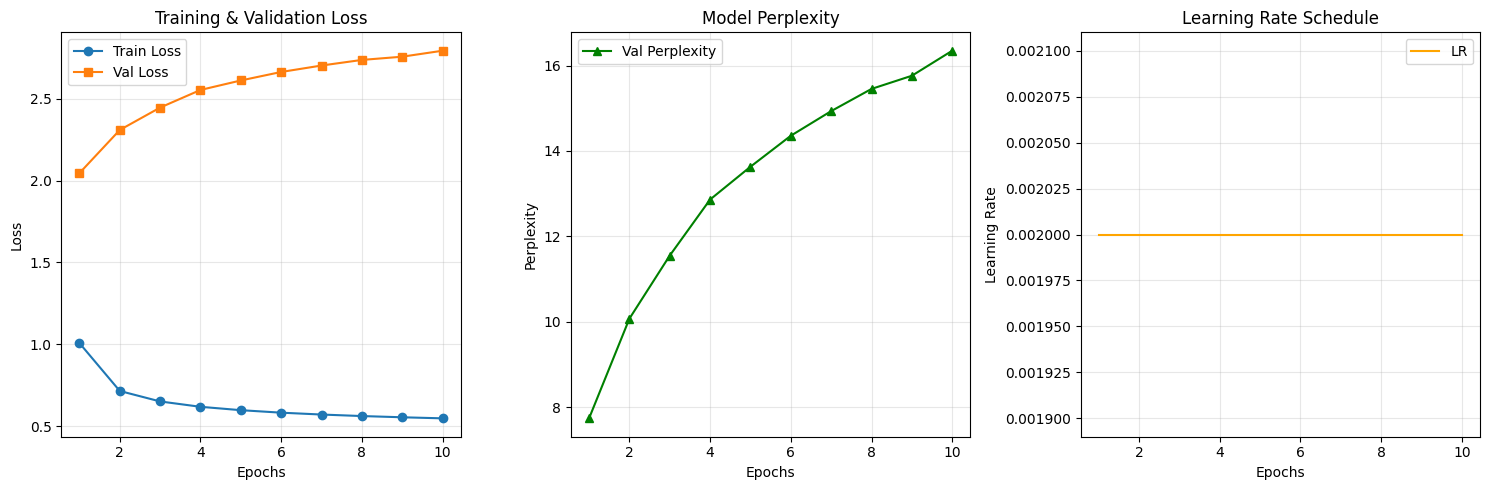

In [15]:
def plot_training_results(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(15, 5))

    # Plot 1: Cross-Entropy Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], 'o-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 's-', label='Val Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: Perplexity (The "Intelligence" Metric)
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['val_ppl'], 'g^-', label='Val Perplexity')
    plt.title('Model Perplexity')
    plt.xlabel('Epochs')
    plt.ylabel('Perplexity')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 3: Learning Rate Decay
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['lrs'], 'orange', label='LR')
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    # plt.savefig()

plot_training_results(history)

---
## 4. Model Evaluation & Inference

---

In [20]:
def evaluate_final_model(model, loader, device, vocab_size):
    model.eval()
    total_loss = 0

    print(f"Calculating final metrics on {len(loader)} validation batches...")

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits, _ = model(inputs)

            # Use the passed-in vocab_size
            loss = nn.functional.cross_entropy(
                logits.view(-1, vocab_size),
                targets.view(-1)
            )
            total_loss += loss.item()

    avg_val_loss = total_loss / len(loader)
    perplexity = torch.exp(torch.tensor(avg_val_loss)).item()

    print("\n" + "="*40)
    print(f"{'FINAL EVALUATION REPORT':^40}")
    print("="*40)
    print(f"Validation Loss: {avg_val_loss:.4f}")
    print(f"Perplexity:      {perplexity:.2f}")
    print("="*40)

    # 500 characters is the "Goldilocks" length for checking consistency
    print("\nLONG GENERATION (Temp=0.7):")
    print("-" * 40)
    print(generate_text(model, seed="KING RICHARD: ", length=500, temperature=0.7))
    print("-" * 40)


In [21]:
import requests

# 1. Fetch the Sonnets (Distinct from the 'Plays' in Tiny Shakespeare)
sonnets_url = "https://www.gutenberg.org/cache/epub/1041/pg1041.txt"
sonnets_text = requests.get(sonnets_url).text

# 2. Basic cleaning (Project Gutenberg adds headers/footers)
# We look for the actual start and end of the poems
start_idx = sonnets_text.find("I")
end_idx = sonnets_text.rfind("FINIS")
sonnets_clean = sonnets_text[start_idx:end_idx]

# 3. CRITICAL: Filter for characters your model actually knows
# Your model will crash if it sees a character it wasn't trained on (like a weird symbol)
sonnets_filtered = "".join([c for c in sonnets_clean if c in vocab])

# 4. Create the Out-of-Distribution (OOD) Test Set
test_ds_sonnets = CharDataset(sonnets_filtered, SEQ_LEN)
test_loader_sonnets = DataLoader(test_ds_sonnets, batch_size=BATCH_SIZE, shuffle=False)

print(f"New Test Set (Sonnets) loaded with {len(test_loader_sonnets)} batches.")

New Test Set (Sonnets) loaded with 447 batches.


In [22]:
print("--- INTERNAL VALIDATION (Same style) ---")
evaluate_final_model(model, val_loader, DEVICE, VOCAB_SIZE)

print("\n--- EXTERNAL TEST (Sonnets - Different style) ---")
evaluate_final_model(model, test_loader_sonnets, DEVICE, VOCAB_SIZE)

--- INTERNAL VALIDATION (Same style) ---
Calculating final metrics on 436 validation batches...

        FINAL EVALUATION REPORT         
Validation Loss: 2.7940
Perplexity:      16.35

LONG GENERATION (Temp=0.7):
----------------------------------------
KING RICHARD: use that thou art not her?
Your house, and come about her breast:
As never-let her hence to France to fell for love
As doth the town and find the scandal of bitter
Some tribunes, and be agreed;
Our doth relent, as the air with all dissending them.
O, he would have alone resolute of my traitor!
You were not be a lace-worse, or approved well;
Im absolmition are a bawd.

AUTOLYCUS:

Clown:
Prepare you, lords: O, he is grown your hands,
Thine being but a mind to her acceptain thee:
Thou, brace that 
----------------------------------------

--- EXTERNAL TEST (Sonnets - Different style) ---
Calculating final metrics on 447 validation batches...

        FINAL EVALUATION REPORT         
Validation Loss: 3.9944
Perplexity:      

In [19]:
%watermark -iv

datasets   : 4.0.0
matplotlib : 3.10.0
numpy      : 2.0.2
pandas     : 2.2.2
re         : 2.2.1
requests   : 2.32.4
sklearn    : 1.6.1
torch      : 2.10.0+cu128
torchinfo  : 1.8.0
torchvision: 0.25.0+cu128

